In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering

In [20]:
penguins = pd.read_table("penguins.txt", sep = ",").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


KMeans clustering works by iteratively grouping observations that are nearby one another in variable space. Using the penguins dataset, we'll use KMeans clustering to try and group observations based on their anatomical similarity and see how the resulting clusters compare to their species.

We'll start with just three of the anatomical variables.

In [21]:
X = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]]

Find 3 clusters, each one representing a simulated species.

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3).fit(X)

Extract the cluster labels, extracting the cluster assigned to each observation.

In [23]:
penguins["cluster"] = kmeans.labels_

In [24]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,2
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,0


Now visualize the association between our 3 variables.

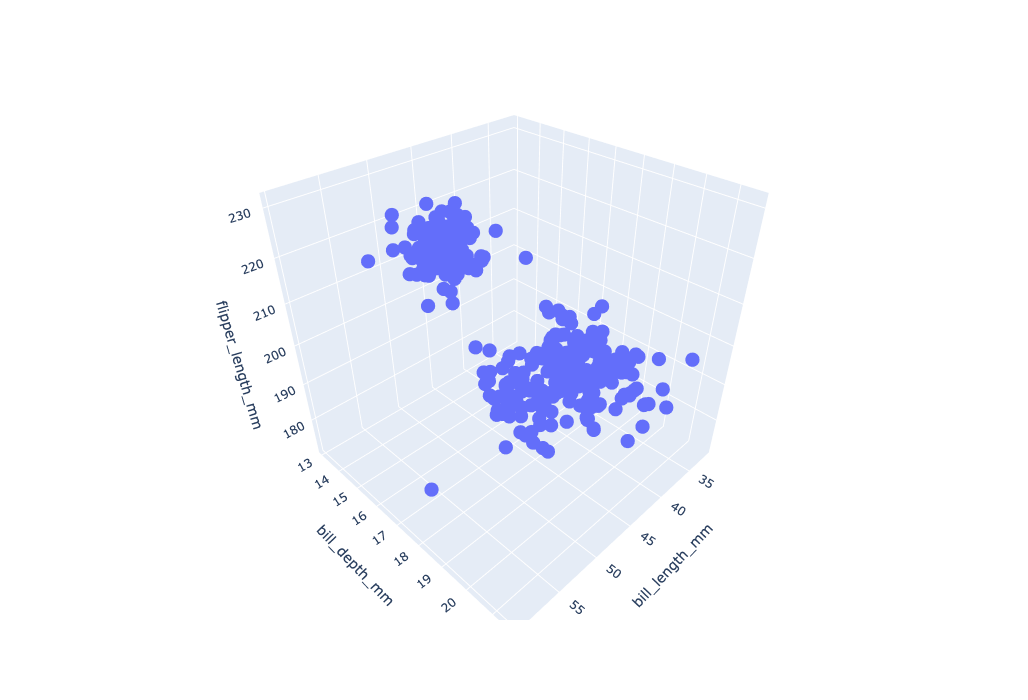

In [26]:
import plotly.express as px

fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "flipper_length_mm")
fig.update_layout(height=700)

Look at how these data associate with respect to their species.

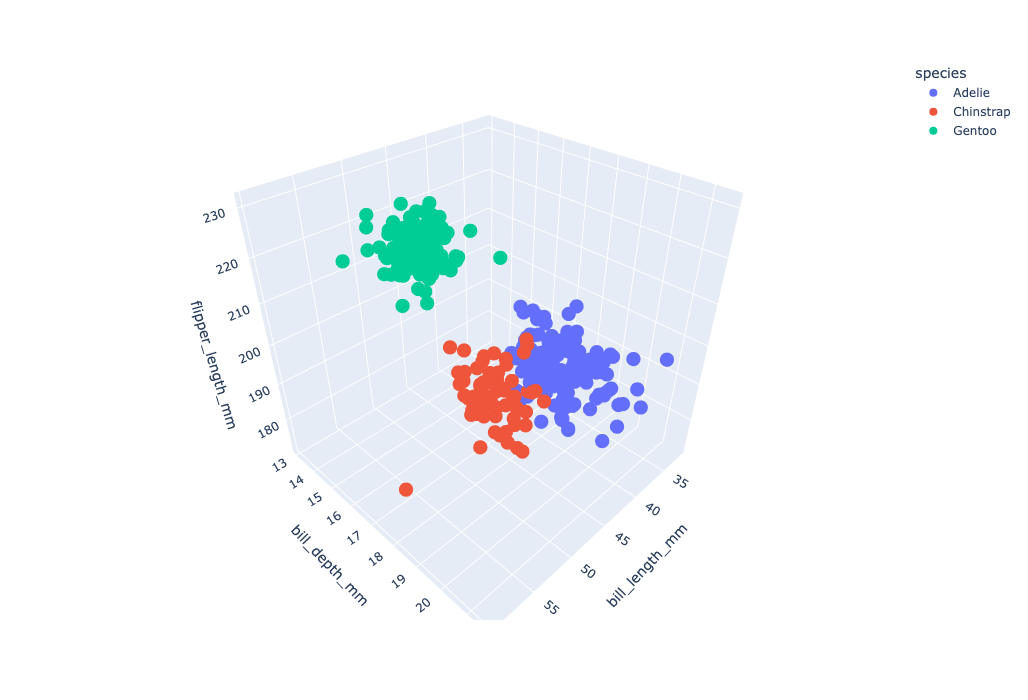

In [28]:
fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "flipper_length_mm", color = "species")
fig.update_layout(height=700)

There are three clear groups of points distinctly associated with one of each species. The fact that they are so well separated along these anatomical variables suggests that we should be able to capture some of that structure via clustering.

Now compare with clusters

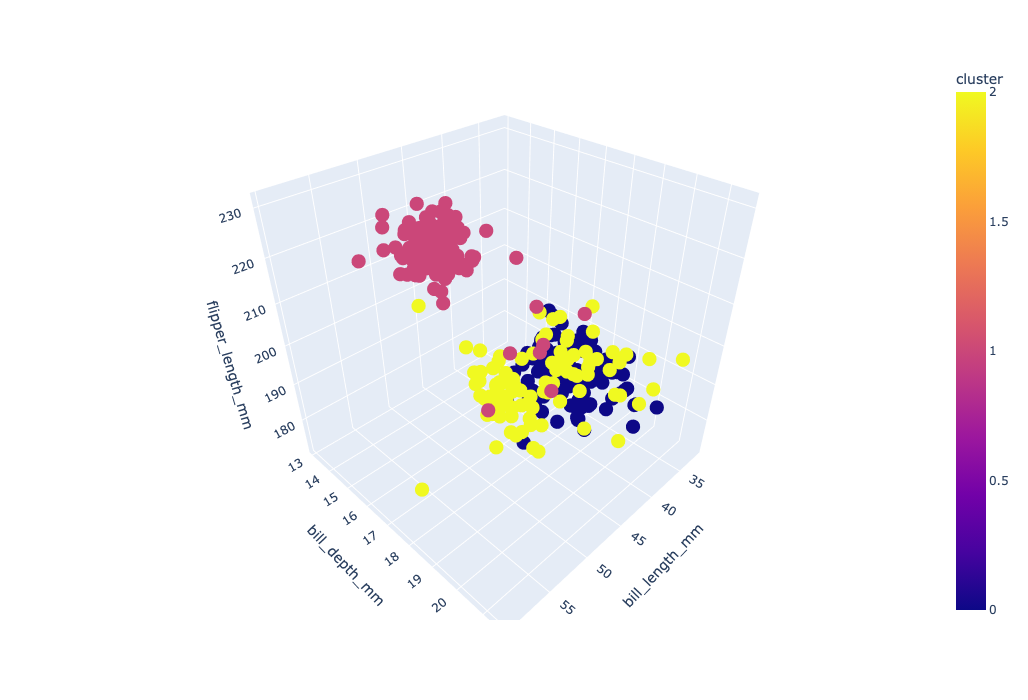

In [30]:
fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "flipper_length_mm", color = "cluster")
fig.update_layout(height=700)

Fairly similar! The clustering algorithm separates the species particularly well along the bill anatomical characterstics, notably without any reference to the species labels themselves.

Now try with a different three variables, replacing flipper length with body mass.

In [31]:
X = penguins[["bill_length_mm", "bill_depth_mm", "body_mass_g"]]
kmeans = KMeans(n_clusters=3).fit(X)

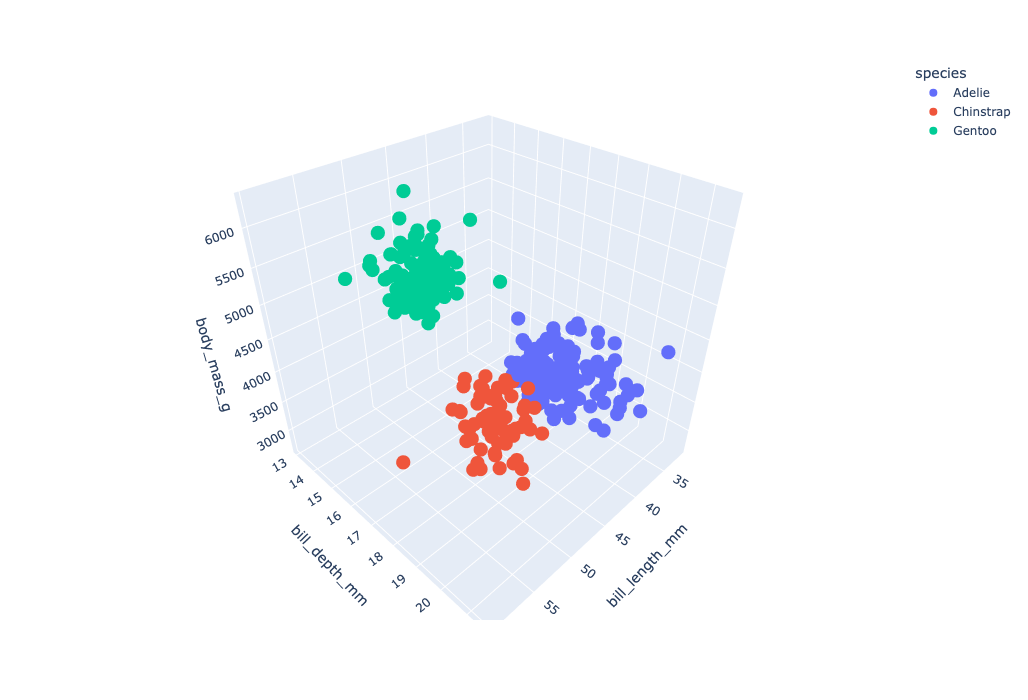

In [32]:
import plotly.express as px

fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "body_mass_g", color = "species")
fig.update_layout(height=700)

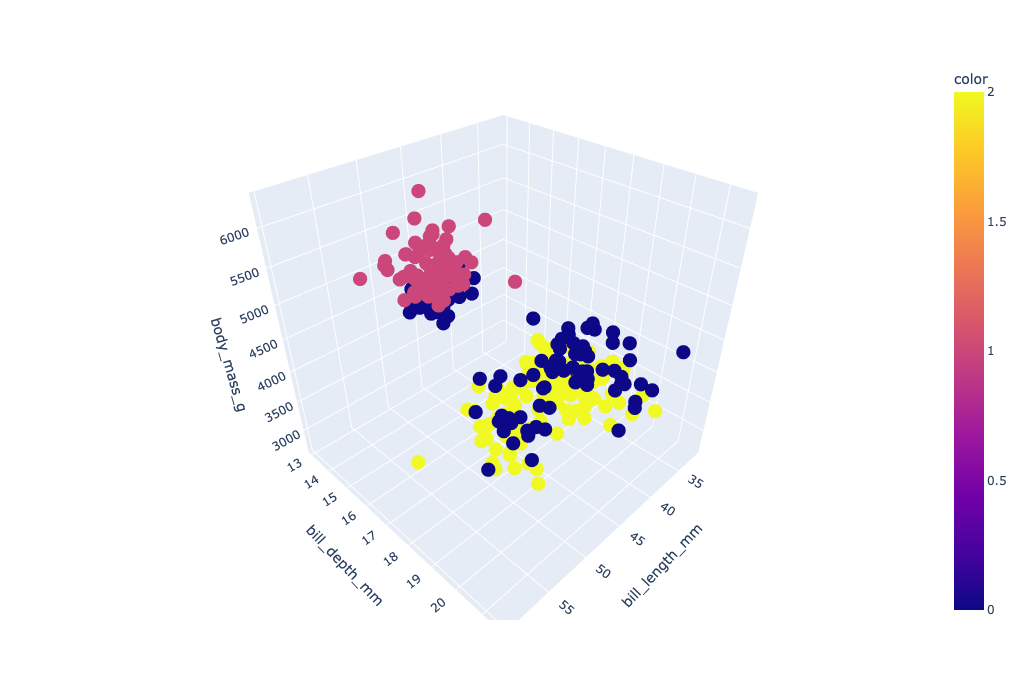

In [33]:
fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "body_mass_g", color = kmeans.labels_)
fig.update_layout(height=700)

The clustering algorithm does significantly worse when using body mass instead. 

There's a good reason for this: the previous variables all had roughly the same scale using the same units (mm), while body mass is on a different scale with different units.

In [34]:
penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


Because of the difference in scale, body mass dominated the algorithm such that differences in body mass were disproportionately weighted relative to differences in other measurements (this occured with flipper length as well, though to a lesser degree).

The solution is to standardize our variables.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
penguins_scaled = pd.DataFrame(data=X_scaled, columns=X.columns)
penguins_scaled.head(10)

,bill_length_mm,bill_depth_mm,body_mass_g
0,-0.896042,0.780732,-0.568475
1,-0.822788,0.119584,-0.506286
2,-0.676280,0.424729,-1.190361
3,-1.335566,1.085877,-0.941606
4,-0.859415,1.747026,-0.692852
5,-0.932669,0.323014,-0.723946
6,-0.877728,1.238450,0.582014
7,-0.529772,0.221299,-1.252549
8,-0.987609,2.052171,-0.506286
9,-1.720150,2.001313,0.239977


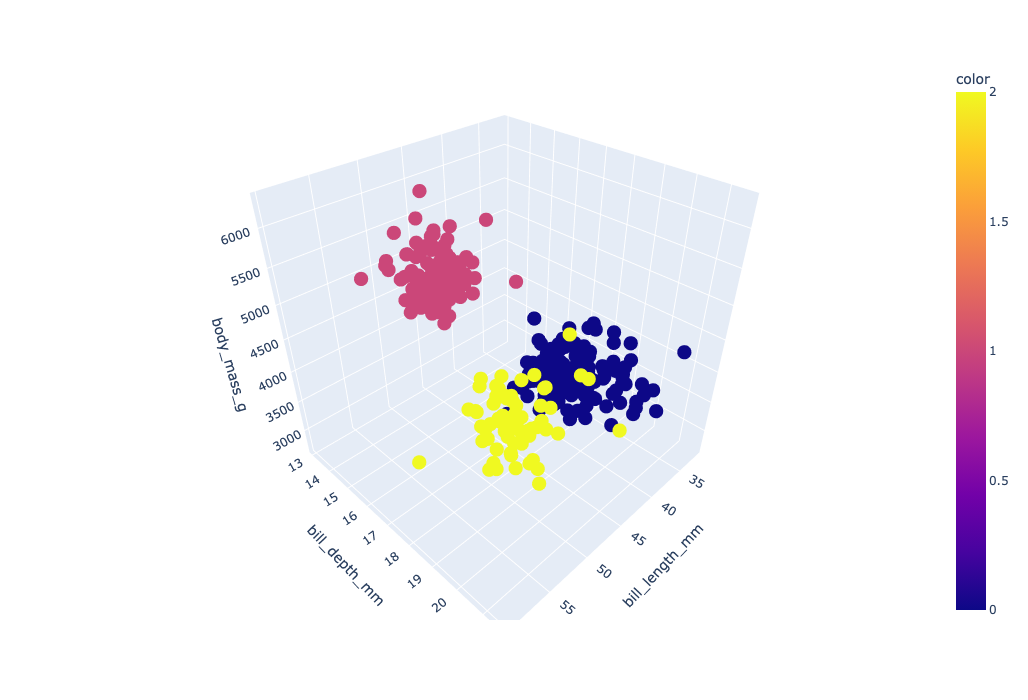

In [36]:
kmeans = KMeans(n_clusters=3).fit(penguins_scaled)
fig = px.scatter_3d(penguins, x = "bill_length_mm", y = "bill_depth_mm", z = "body_mass_g", color = kmeans.labels_)
fig.update_layout(height=700)

With the scaled variables, the clustering now recapitulates the species extremely well!

Obviously we already knew the species of the penguins before doing the clustering. However the point of this exercise was to demonstrate how clustering can algorithmically identify higher-dimensional association of observations that (can) map to real phenomena.